In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from config import *
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

In [2]:
# data = pd.read_csv(os.path.join(DATA_RAW_DIR, 'MELBOURNE_HOUSE_PRICES_LESS.csv'))
df = pd.read_csv(os.path.join(DATA_EXTERNAL_DIR, 'data_joins.csv'))

df['fec_venta'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce').dt.strftime('%Y%m')
df['anio_construccion'] = df['YearBuilt'].astype('Int64')
df['metodo'] = df['Method'].str.strip().map({
    'S':  'prop_vendida',
    'SP': 'prop_vendida_prev',
    'PI': 'prop_transferida',
    'PN': 'vendida_prev_no_divulgada',
    'SN': 'vendida_no_divulgada',
    'VB': 'puja_del_vendedor',
    'W':  'retirada_antes_subasta',
    'SA': 'vendida_despues_subasta',
    'SS': 'vendida_despues_subasta_no_divulgada'
}).fillna('otro')
df['target'] = df['Price']
df = df[df['Price'].notna() & df['Regionname'].notna()]

df['Landsize'] =  np.log1p(df.Landsize)
df = df[df['Landsize'].notna()]

df['Car'] = df['Car'].fillna(0)

df['target'] = np.log1p(df.target)


df['dif_fechas'] = df[['fec_venta', 'anio_construccion']].apply(
    lambda row: int(str(row['fec_venta'])[:4]) - row['anio_construccion']
    if pd.notnull(row['fec_venta']) and pd.notnull(row['anio_construccion']) else np.nan,
    axis=1
)
df['dif_fechas'] = df['dif_fechas'].fillna(0)
df['dif_fechas'] = df['dif_fechas'].infer_objects(copy=False)
df.drop(columns=['fec_venta', 'anio_construccion'], inplace=True)
df['dif_fechas'] = np.log1p(df['dif_fechas'].clip(lower=0))

df.drop(columns=['YearBuilt', 'Lattitude', 'Longtitude', 'BuildingArea', 'Price', 'Postcode'], axis = 1 , inplace=True, errors='ignore')

## Repetidos
df.drop(columns=['Method', 'Date', 'SellerG', 'Address', 'Suburb'], axis = 1 , inplace=True, errors='ignore')

df.dropna(inplace=True)

In [3]:
df.select_dtypes(exclude=np.number).columns

Index(['Type', 'CouncilArea', 'Regionname', 'metodo'], dtype='object')

In [4]:
var_category = ['Type', 'CouncilArea', 'Regionname', 'metodo']
var_numeric = [i for i in df.columns.to_list() if i not in var_category]
for var in var_category:
    df[var] = df[var].astype('category')

for var in var_numeric:
    df[var] = df[var].astype(float)

In [5]:
from src.analysis import analyze_outliers_mixed_data

In [6]:
df.select_dtypes(include = np.number).columns

Index(['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'Propertycount', 'Comercio y servicios', 'Restauración y vida social',
       'Transporte y conectividad', 'Cultura y recreación', 'Financiero',
       'Espiritual y comunitario', 'Salud', 'Educación', 'target',
       'dif_fechas'],
      dtype='object')

In [7]:
df.select_dtypes(exclude = np.number).columns

Index(['Type', 'CouncilArea', 'Regionname', 'metodo'], dtype='object')

In [8]:
df.describe()

,Rooms,Distance,Bedroom2,Bathroom,Car,Landsize,Propertycount,Comercio y servicios,Restauración y vida social,Transporte y conectividad,Cultura y recreación,Financiero,Espiritual y comunitario,Salud,Educación,target,dif_fechas
count,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000,17973.000000
mean,3.050019,11.107372,3.033050,1.580871,1.673176,5.466236,7472.720358,37.794636,22.026818,47.831358,3.356535,2.184109,1.657264,2.611139,1.114060,13.767073,2.124801
std,0.942659,6.670443,0.954926,0.702912,1.012559,2.015896,4389.793779,68.149826,52.941887,35.103751,3.299564,4.411214,2.025471,3.326703,1.403157,0.518407,1.929887
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,83.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.350418,0.000000
25%,2.000000,6.400000,2.000000,1.000000,1.000000,5.393628,4380.000000,6.000000,2.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.399997,0.000000
50%,3.000000,10.300000,3.000000,1.000000,2.000000,6.240276,6543.000000,16.000000,7.000000,40.000000,3.000000,1.000000,1.000000,2.000000,1.000000,13.729954,2.484907
75%,4.000000,13.900000,4.000000,2.000000,2.000000,6.499787,10331.000000,41.000000,22.000000,68.000000,5.000000,3.000000,2.000000,4.000000,2.000000,14.115616,4.043051
max,12.000000,48.100000,20.000000,9.000000,18.000000,12.978528,21650.000000,894.000000,946.000000,262.000000,27.000000,71.000000,13.000000,35.000000,12.000000,16.231424,6.711740


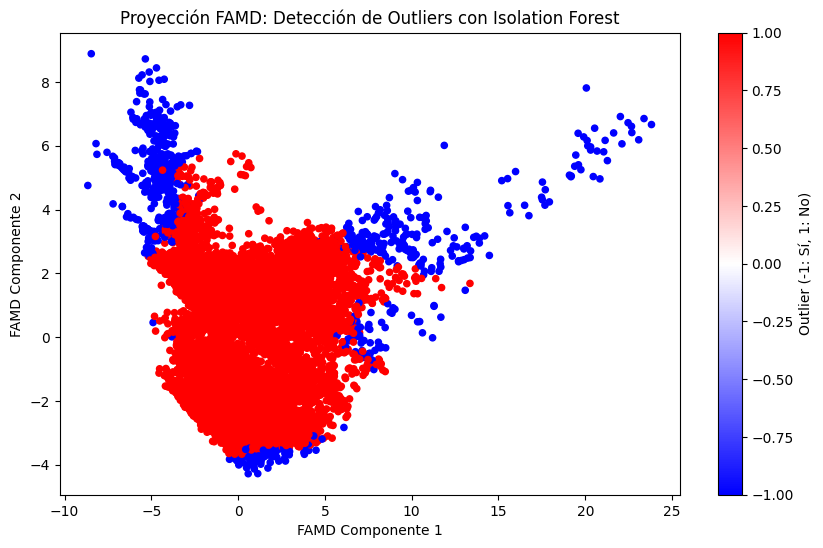

Outliers detectados y eliminados: 899


In [9]:
cleaned_data, scaler, famd, iso_forest = analyze_outliers_mixed_data(
    df, 
    ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'Propertycount', 'Comercio y servicios',
       'Restauración y vida social', 'Transporte y conectividad',
       'Cultura y recreación', 'Financiero', 'Espiritual y comunitario',
       'Salud', 'Educación', 'dif_fechas'], 
    ['Type', 'CouncilArea', 'Regionname', 'metodo'], 
    contamination=0.05, 
    plot=True
)

In [10]:
cleaned_data.head(2)

,Rooms,Type,Distance,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Regionname,Propertycount,Comercio y servicios,Restauración y vida social,Transporte y conectividad,Cultura y recreación,Financiero,Espiritual y comunitario,Salud,Educación,metodo,target,dif_fechas
1,2.0,h,2.5,2.0,1.0,1.0,5.313206,Yarra City Council,Northern Metropolitan,4019.0,111.0,35.0,42.0,12.0,6.0,3.0,0.0,1.0,prop_vendida,14.207553,0.000000
2,2.0,h,2.5,2.0,1.0,0.0,5.056246,Yarra City Council,Northern Metropolitan,4019.0,206.0,125.0,83.0,13.0,8.0,6.0,8.0,2.0,prop_vendida,13.849913,4.762174


<Axes: xlabel='target', ylabel='Count'>

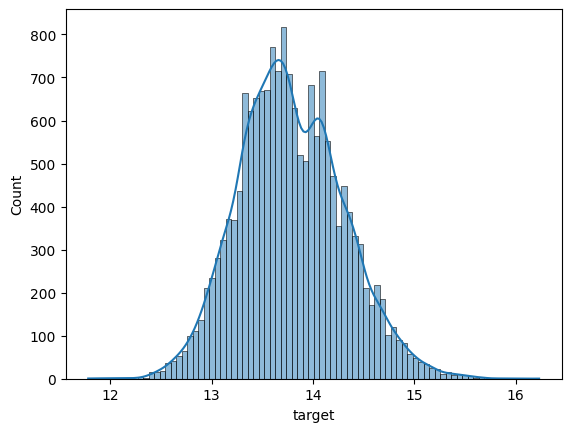

In [11]:
import seaborn as sns
sns.histplot(data = cleaned_data, x = 'target', kde=True)

$$
\ln \hat{p}^{\tau}_i = \ln \beta_0 + \sum_{k=1}^{K} z^{\tau}_{k,i} \ln \hat{\beta}_k + \sum_{d=1}^{10} \gamma^d D^d + \hat{\varepsilon}_i
$$

**Donde:**

- $i$: es el identificador de cada departamento.
- $k$: es el identificador de cada característica.
- $d$: es el identificador de cada distrito.
- $\ln \hat{p}^{0,\tau}_i$: es el logaritmo del precio de venta del departamento $i$. Se consideran las observaciones desde el periodo 0 hasta el periodo $\tau$.
- $z^{0,\tau}_{k,i}$: es la característica $k$ del departamento $i$. Se consideran las observaciones desde el periodo 0 hasta el periodo $\tau$.
- $\hat{\beta}_k$: es el coeficiente estimado para la característica $k$.
- $D^d$: es la variable binaria de distrito. Captura todas las características diferentes a $Z$ propias de cada distrito $d$.
- $\gamma^d$: es el coeficiente de la variable binaria del distrito $d$.
- $\hat{\varepsilon}_i$: es el error de estimación.


In [12]:
cleaned_data.target.describe(percentiles=[0.25,0.5,0.75,0.9,0.99])

count    17074.000000
mean        13.784426
std          0.513873
min         11.782960
25%         13.424135
50%         13.744016
75%         14.123731
90%         14.457365
99%         15.068274
max         16.231424
Name: target, dtype: float64

In [ ]:
cleaned_data.head(2)

In [ ]:
from src.analysis import analisis_variables_numericas_continuo 
analisis_variables_numericas_continuo(cleaned_data,'target')